# HW1 — Roofline & Arithmetic Intensity

**Lecture mapping:** L1 §06 (Roofline) · L1 §03 (GPU architecture)

Measure real GPU kernels and plot them on the roofline for your card.

```
achievable_perf = min( peak_compute,  peak_bandwidth × arithmetic_intensity )
arithmetic_intensity (FLOP/byte) = FLOPs / bytes moved to-from HBM
```

The ridge point is at `peak_compute / peak_bandwidth` (≈ 295 FLOP/byte on an
H100). Left of it: memory-bound. Right of it: compute-bound.

## What you implement

| Part | Function |
|------|----------|
| 1a | `lowest_ai_fn` — lowest-arithmetic-intensity elementwise op |
| 1b | `make_compute_fn` — tunable-K kernel, eager and compiled |
| 2  | `benchmark_fn` — timing with CUDA events + warmup |
| 3  | `compute_metrics` — measurements → (AI, TFLOP/s, GB/s) |
| 4  | Writeup Q1–Q2 |

## Cell types

- **DO NOT EDIT** — fixed harness.
- **YOUR IMPLEMENTATION** — replace `raise NotImplementedError`.
- **SELF-CHECK** — asserts that must pass.
- **WRITEUP** — answer in the markdown cell.

Run top-to-bottom on the GPU (H100 / L40S / T4). The self-check also runs on CPU.
Submit the executed notebook plus the files under `results/`.

## Setup — hardware specs & helpers (DO NOT EDIT)

In [1]:
# DO NOT EDIT — hardware specs, dtype helpers.
from dataclasses import dataclass
from typing import Callable
import json, math, os, time

import torch

RESULTS_DIR = os.path.join("results", "hw1")
os.makedirs(RESULTS_DIR, exist_ok=True)


@dataclass(frozen=True)
class GpuSpec:
    name: str
    peak_flops: float   # peak tensor FLOP/s for the benchmark dtype (BF16)
    peak_bw: float      # peak HBM bandwidth, bytes/s
    vram_gb: float

    @property
    def ridge_ai(self) -> float:
        """Arithmetic intensity (FLOP/byte) at the roofline ridge point."""
        return self.peak_flops / self.peak_bw


# Vendor spec sheets. BF16 tensor-core peak (dense, no sparsity) and HBM BW.
H100_SXM = GpuSpec("H100 SXM", peak_flops=989e12, peak_bw=3.35e12, vram_gb=80)
L40S = GpuSpec("L40S", peak_flops=362e12, peak_bw=0.864e12, vram_gb=48)
# CPU fallback so the notebook runs for a smoke test off-GPU. The numbers are
# placeholders — only GPU runs produce meaningful results.
CPU_FALLBACK = GpuSpec("CPU (fallback)", peak_flops=1e12, peak_bw=50e9, vram_gb=8)


def detect_hardware() -> GpuSpec:
    if not torch.cuda.is_available():
        print("CUDA not available — using CPU fallback spec. "
              "Results are NOT meaningful; run on H100/L40S.")
        return CPU_FALLBACK
    name = torch.cuda.get_device_name(0)
    if "H100" in name:
        return H100_SXM
    if "L40" in name:
        return L40S
    print(f"Unrecognized GPU '{name}'. Defaulting to H100 ceilings; "
          f"ask the instructor to add your card's spec.")
    return H100_SXM


def benchmark_dtype() -> torch.dtype:
    """BF16 on GPU (tensor cores, matches the spec peak); float32 on CPU."""
    return torch.bfloat16 if torch.cuda.is_available() else torch.float32


def dtype_bytes(dtype: torch.dtype) -> int:
    return torch.empty(0, dtype=dtype).element_size()


SPEC = detect_hardware()
DTYPE = benchmark_dtype()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={DEVICE} dtype={DTYPE} spec={SPEC.name} "
      f"peak={SPEC.peak_flops/1e12:.0f} TFLOP/s bw={SPEC.peak_bw/1e12:.2f} TB/s "
      f"ridge≈{SPEC.ridge_ai:.0f} FLOP/byte")

Unrecognized GPU 'NVIDIA A100-SXM4-40GB'. Defaulting to H100 ceilings; ask the instructor to add your card's spec.
device=cuda dtype=torch.bfloat16 spec=H100 SXM peak=989 TFLOP/s bw=3.35 TB/s ridge≈295 FLOP/byte


In [2]:
# DO NOT EDIT — roofline plotting.
def plot_roofline(points: list, spec: GpuSpec, out_path: str) -> None:
    """Render measured (AI, achieved TFLOP/s) points under the roofline.

    points: list of {"label", "ai", "achieved_tflops", "series"}.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(8, 6))

    # Roofline: memory ceiling (slope = BW) then flat compute ceiling.
    ai_grid = np.logspace(-2, 4, 400)
    peak_tflops = spec.peak_flops / 1e12
    bw_tflops_per_ai = spec.peak_bw / 1e12  # (TFLOP/s) per (FLOP/byte)
    roof = np.minimum(peak_tflops, bw_tflops_per_ai * ai_grid)
    ax.plot(ai_grid, roof, "k-", lw=2, label="roofline")
    ax.axhline(peak_tflops, ls="--", c="gray", lw=1)
    ax.axvline(spec.ridge_ai, ls=":", c="gray", lw=1,
               label=f"ridge ≈ {spec.ridge_ai:.0f} FLOP/byte")

    series = {}
    for p in points:
        series.setdefault(p.get("series", "ops"), []).append(p)
    for name, pts in series.items():
        pts = sorted(pts, key=lambda d: d["ai"])
        xs = [d["ai"] for d in pts]
        ys = [d["achieved_tflops"] for d in pts]
        ax.plot(xs, ys, "o-", ms=7, label=name)
        for d in pts:
            ax.annotate(d["label"], (d["ai"], d["achieved_tflops"]),
                        textcoords="offset points", xytext=(6, 4), fontsize=7)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Arithmetic intensity (FLOP / byte)")
    ax.set_ylabel("Achieved performance (TFLOP/s)")
    ax.set_title(f"Roofline — {spec.name}")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, which="both", ls=":", alpha=0.4)
    fig.tight_layout()
    fig.savefig(out_path, dpi=130)
    plt.show()
    print(f"wrote {out_path}")

## Part 1a — lowest-AI op

Return a no-argument function that does one elementwise pass over `x` and returns
a same-size tensor. Aim for the lowest arithmetic intensity: a few FLOPs per
element, one read and one write. This should land on the memory-bound (left)
side of the roofline.

In [3]:
# TODO-CELL: lowest_ai_fn
# YOUR IMPLEMENTATION
def lowest_ai_fn(x: torch.Tensor) -> Callable[[], torch.Tensor]:
    """Return a no-argument function doing one cheap elementwise pass over x.

    e.g. return lambda: x * 2.0
    """
    return lambda: x * 2.0

## Part 1b — tunable-intensity kernel

Return a no-argument function that applies `k` chained elementwise ops to `x`,
each feeding into the next. Ideal arithmetic intensity grows with `k`: you load
`x` once and do `k×` the work. In eager mode each step is a separate kernel with
its own HBM round-trip, so achieved intensity stays low. The run cell also wraps
your function in `torch.compile`, which fuses the steps and moves the point
toward the compute roof.

Chain real data dependencies through `x` so the steps can't be constant-folded.

In [4]:
# TODO-CELL: make_compute_fn
# YOUR IMPLEMENTATION
def make_compute_fn(x: torch.Tensor, k: int) -> Callable[[], torch.Tensor]:
    """Return a no-argument function applying k chained elementwise ops to x.
    Must not mutate x."""
    def fn():
        y = x
        for _ in range(k):
            y = torch.sin(y)
        return y
    return fn

## Part 2 — timing with CUDA events

GPU launches are asynchronous, so `time.time()` measures how fast Python queued
the kernel, not how long the GPU ran it. Time with
`torch.cuda.Event(enable_timing=True)` and synchronize before reading.

In [5]:
# TODO-CELL: benchmark_fn
# YOUR IMPLEMENTATION
def benchmark_fn(fn: Callable[[], torch.Tensor],
                 n_warmup: int = 10, n_iters: int = 50) -> float:
    """Time ``fn`` and return the AVERAGE wall time per call, in SECONDS.

    Requirements:
      * Run ``n_warmup`` un-timed calls first (let cuBLAS pick kernels, let
        torch.compile finish compiling).
      * Time ``n_iters`` calls. On CUDA use torch.cuda.Event(enable_timing=True)
        and synchronize before reading the elapsed time.
      * On CPU (no CUDA) fall back to time.perf_counter.
    Return seconds-per-call (elapsed_total / n_iters).
    """
    for _ in range(n_warmup):
          fn()  # Warmup calls

    if torch.cuda.is_available():
      start = torch.cuda.Event(enable_timing=True)
      end   = torch.cuda.Event(enable_timing=True)
      start.record()
      for _ in range(n_iters):
          fn()
      end.record()
      torch.cuda.synchronize()
      elapsed_total_s = start.elapsed_time(end) / 1000.0   # ms → s  (REQUIRED)
    else:
      t0 = time.perf_counter()
      for _ in range(n_iters):
          fn()
      elapsed_total_s = time.perf_counter() - t0           # already seconds

    return elapsed_total_s / n_iters                         # always a float

## Part 3 — measurements → roofline coordinates

In [6]:
# TODO-CELL: compute_metrics
# YOUR IMPLEMENTATION
def compute_metrics(flops: float, bytes_moved: float, seconds: float) -> dict:
    """Convert a measurement into roofline coordinates.

    Args:
        flops:       total floating-point ops the kernel performed.
        bytes_moved: total bytes moved to/from HBM (load inputs once + store
                     output once — the *ideal* traffic).
        seconds:     measured time per call (from benchmark_fn).

    Return a dict with EXACTLY these keys:
        {
          "ai":              FLOPs per byte,
          "achieved_tflops": achieved compute in TFLOP/s,
          "achieved_gbps":   achieved bandwidth in GB/s,
        }
    """
    return {"ai": flops / bytes_moved,
            "achieved_tflops": flops / seconds / 1e12,
            "achieved_gbps": bytes_moved / seconds / 1e9}

## Self-check

Fast asserts (run anywhere). Passing doesn't mean the plot and writeup are done;
failing means something is wrong.

In [7]:
# SELF-CHECK — DO NOT EDIT.
torch.manual_seed(0)
_x = torch.randn(4096).abs() + 0.1

m = compute_metrics(flops=2e12, bytes_moved=1e9, seconds=1e-3)
assert set(m) == {"ai", "achieved_tflops", "achieved_gbps"}, set(m)
assert math.isclose(m["ai"], 2000, rel_tol=1e-6), m["ai"]
assert math.isclose(m["achieved_tflops"], 2000, rel_tol=1e-6), m["achieved_tflops"]
assert math.isclose(m["achieved_gbps"], 1000, rel_tol=1e-6), m["achieved_gbps"]
print("compute_metrics   PASS")

_y = lowest_ai_fn(_x)()
assert torch.is_tensor(_y) and _y.numel() == _x.numel(), "must return a same-size tensor"
print("lowest_ai_fn      PASS")

_x0 = _x.clone()
_g1 = make_compute_fn(_x, 1)()
_g8 = make_compute_fn(_x, 8)()
assert torch.allclose(_x, _x0), "make_compute_fn must not mutate its input"
assert torch.is_tensor(_g8), "must return a tensor"
assert not torch.allclose(_g1, _g8), "k must actually change the result (real data dependency)"
print("make_compute_fn   PASS")

_t_light = benchmark_fn(lambda: _x * 2.0, n_warmup=2, n_iters=5)
_t_heavy = benchmark_fn(
    lambda: _x.unsqueeze(0).repeat(256, 1) @ _x.unsqueeze(1).repeat(1, 256),
    n_warmup=2, n_iters=5)
assert isinstance(_t_light, float) and _t_light > 0, "must return positive seconds as float"
assert _t_heavy >= _t_light * 0.5, "a much heavier op should not be much faster"
print("benchmark_fn      PASS")
print()
print("All checks passed")

compute_metrics   PASS
lowest_ai_fn      PASS
make_compute_fn   PASS
benchmark_fn      PASS

All checks passed


## Run on the GPU

Benchmarks ops from low to high arithmetic intensity with your `benchmark_fn`,
converts them with your `compute_metrics`, and plots the roofline.

A correct plot:
- all points sit below the roofline;
- `elementwise` and small-`K` `compute-K` sit low on the left (memory-bound);
- `matmul-N` climbs up and to the right toward the compute ceiling as `N` grows;
- compiled `compute-K` sits above eager at the same intensity (what compilation buys).

elementwise:     53.4 us  AI=0.25  1257 GB/s
compute-K [eager] done
compute-K [compiled] done
matmul N=1024:   0.019 ms  AI=341  111 TFLOP/s
matmul N=2048:   0.107 ms  AI=683  160 TFLOP/s
matmul N=4096:   0.510 ms  AI=1.37e+03  270 TFLOP/s
wrote results/hw1/roofline_data.json


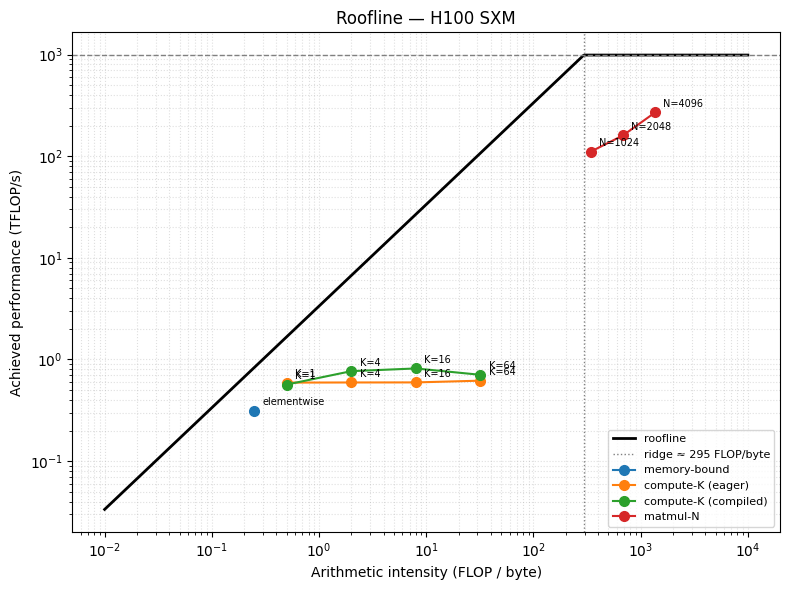

wrote results/hw1/roofline.png


In [8]:
# DO NOT EDIT — the sweep + plot. (Trimmed automatically on CPU.)
ELEM_N = 1 << 24 if torch.cuda.is_available() else 1 << 18      # vector length
COMPUTE_KS = [1, 4, 16, 64]                                     # ops per element
MATMUL_NS = [1024, 2048, 4096] if torch.cuda.is_available() else [128, 256]


def _try_compile(fn):
    try:
        c = torch.compile(fn)
        c()  # force a trace now so failures surface here
        return c
    except Exception as e:
        print(f"torch.compile unavailable ({type(e).__name__}); "
              f"using eager for the compiled series.")
        return fn


dbytes = dtype_bytes(DTYPE)
points = []

# --- Part 1a: lowest arithmetic intensity (memory-bound) ----------------
x = torch.randn(ELEM_N, device=DEVICE, dtype=DTYPE).abs() + 0.1
fn = lowest_ai_fn(x)
t = benchmark_fn(fn)
# Convention for this op: ~1 FLOP/element, read x + write y.
m = compute_metrics(flops=ELEM_N, bytes_moved=2 * ELEM_N * dbytes, seconds=t)
points.append({"label": "elementwise", "series": "memory-bound",
               "ai": m["ai"], "achieved_tflops": m["achieved_tflops"]})
print(f"elementwise: {t*1e6:8.1f} us  AI={m['ai']:.3g}  {m['achieved_gbps']:.0f} GB/s")

# --- Part 1b: compute-K, eager vs compiled ------------------------------
for tag, compiler in (("eager", lambda f: f), ("compiled", _try_compile)):
    for k in COMPUTE_KS:
        base = make_compute_fn(x, k)
        fn = compiler(base)
        t = benchmark_fn(fn)
        flops = 2 * k * ELEM_N                 # mul+add per step
        ideal_bytes = 2 * ELEM_N * dbytes      # load x once, store once
        m = compute_metrics(flops=flops, bytes_moved=ideal_bytes, seconds=t)
        points.append({"label": f"K={k}", "series": f"compute-K ({tag})",
                       "ai": m["ai"], "achieved_tflops": m["achieved_tflops"]})
    print(f"compute-K [{tag}] done")

# --- matmul sweep: anchors the compute-bound side ------------------------
for n in MATMUL_NS:
    a = torch.randn(n, n, device=DEVICE, dtype=DTYPE)
    b = torch.randn(n, n, device=DEVICE, dtype=DTYPE)
    fn = (lambda a=a, b=b: a @ b)
    t = benchmark_fn(fn)
    flops = 2 * n ** 3
    bytes_moved = 3 * n * n * dbytes           # load a, load b, store c
    m = compute_metrics(flops=flops, bytes_moved=bytes_moved, seconds=t)
    points.append({"label": f"N={n}", "series": "matmul-N",
                   "ai": m["ai"], "achieved_tflops": m["achieved_tflops"]})
    print(f"matmul N={n}: {t*1e3:7.3f} ms  AI={m['ai']:.3g}  "
          f"{m['achieved_tflops']:.0f} TFLOP/s")

# --- emit artifacts -------------------------------------------------------
out_json = os.path.join(RESULTS_DIR, "roofline_data.json")
with open(out_json, "w") as f:
    json.dump({"spec": SPEC.name, "dtype": str(DTYPE),
               "peak_tflops": SPEC.peak_flops / 1e12,
               "peak_bw_tbps": SPEC.peak_bw / 1e12,
               "points": points}, f, indent=2)
print(f"wrote {out_json}")
plot_roofline(points, SPEC, os.path.join(RESULTS_DIR, "roofline.png"))

In [9]:
!nvidia-smi --query-gpu=name,memory.total,clocks.max.memory,clocks.max.sm,driver_version --format=csv


name, memory.total [MiB], clocks.max.memory [MHz], clocks.max.sm [MHz], driver_version
NVIDIA A100-SXM4-40GB, 40960 MiB, 1215 MHz, 1410 MHz, 580.82.07


card: NVIDIA A100-SXM4-40GB | SMs: 108 | CC: 8.0
A100 roof: 312 TFLOP/s, 1.56 TB/s, ridge ≈ 201


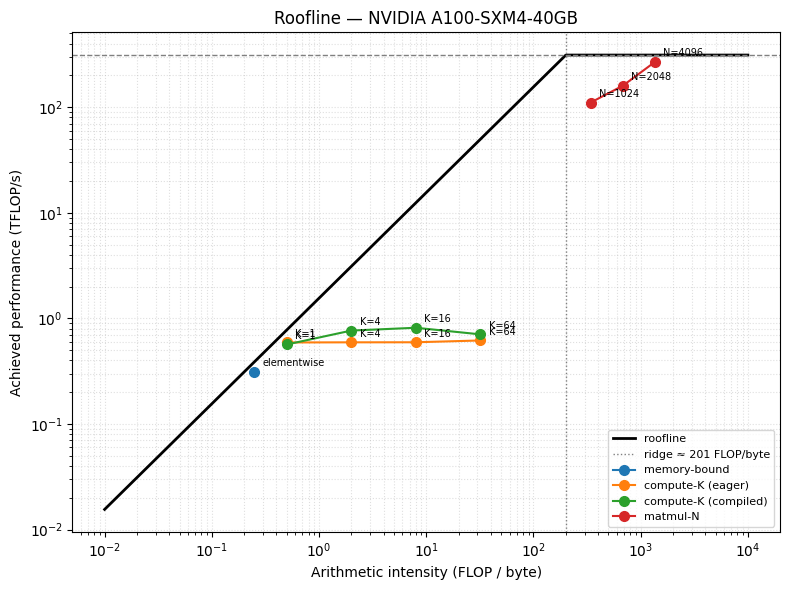

wrote results/hw1/roofline_a100.png


In [10]:
# --- Honest roofline for the ACTUAL card (NEW cell; NOT a DO-NOT-EDIT cell) ---
p = torch.cuda.get_device_properties(0)
print("card:", p.name, "| SMs:", p.multi_processor_count, "| CC:", f"{p.major}.{p.minor}")

clk = getattr(p, "memory_clock_rate", None)   # kHz
bus = getattr(p, "memory_bus_width", None)    # bits
peak_bw = 2 * clk * 1e3 * (bus / 8) if (clk and bus) else 1.555e12   # derived, else datasheet
A100 = GpuSpec(p.name, peak_flops=312e12, peak_bw=peak_bw, vram_gb=p.total_memory / 1e9)
print(f"A100 roof: {A100.peak_flops/1e12:.0f} TFLOP/s, "
      f"{A100.peak_bw/1e12:.2f} TB/s, ridge ≈ {A100.ridge_ai:.0f}")

# reuse the sweep's points (reload from JSON if the runtime was restarted)
try:
    points
except NameError:
    import json
    points = json.load(open(os.path.join(RESULTS_DIR, "roofline_data.json")))["points"]

plot_roofline(points, A100, os.path.join(RESULTS_DIR, "roofline_a100.png"))

---
## WRITEUP

### Q1

Look at your roofline. Which of your points are memory-bound and which are
compute-bound? How can you tell **from the plot alone**?

**Your answer:**

> *(double-click this cell and write your answer here)*

### Q2

For the `matmul-N` series, your points should march up and to the right as `N`
grows. Explain why arithmetic intensity rises with `N` for an N×N×N matmul
(give the rough FLOPs and bytes as a function of `N`).

**Your answer:**

> *(your answer here)*